In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aljarah/xAPI-Edu-Data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'xapi-edu-data' dataset.
Path to dataset files: /kaggle/input/xapi-edu-data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'xAPI-Edu-Data.csv')

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [ ]:
# EDA
# check null values
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [ ]:
df["Class"].value_counts()

,count
Class,
M,211
H,142
L,127


In [ ]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
df['Class'].unique()

array(['M', 'L', 'H'], dtype=object)

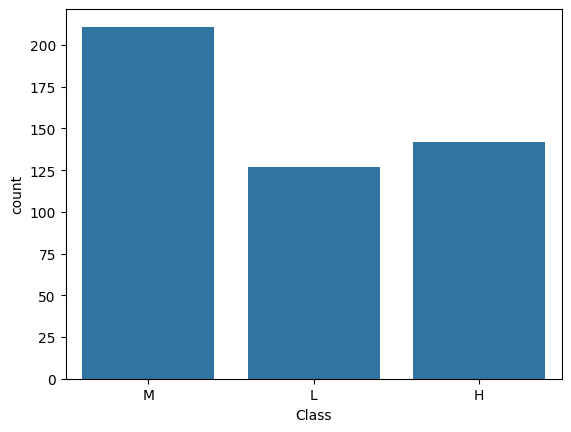

In [ ]:
#data type
# classification type of data ->class imbalance
sns.countplot(x='Class', data=df)
plt.show()


In [ ]:
df.rename(columns={'NationalITy':'National_ITy', 'PlaceofBirth':'Place_of_Birth', 'raisedhands':'Raised_Hands',
                   'VisITedResources':'Visited_Resources', 'AnnouncementsView':'Announcements_View',
                   'ParentAnsweringSurvey':'Parent_Answering_Survey', 'ParentschoolSatisfaction':'Parent_School_Satisfaction',
                   'StudentAbsenceDays':'Student_Absence_Days'},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   gender                      480 non-null    object
 1   National_ITy                480 non-null    object
 2   Place_of_Birth              480 non-null    object
 3   StageID                     480 non-null    object
 4   GradeID                     480 non-null    object
 5   SectionID                   480 non-null    object
 6   Topic                       480 non-null    object
 7   Semester                    480 non-null    object
 8   Relation                    480 non-null    object
 9   Raised_Hands                480 non-null    int64 
 10  Visited_Resources           480 non-null    int64 
 11  Announcements_View          480 non-null    int64 
 12  Discussion                  480 non-null    int64 
 13  Parent_Answering_Survey     480 non-null    object

Now that we have renamed the columns, let's look at the distribution of some categorical features.

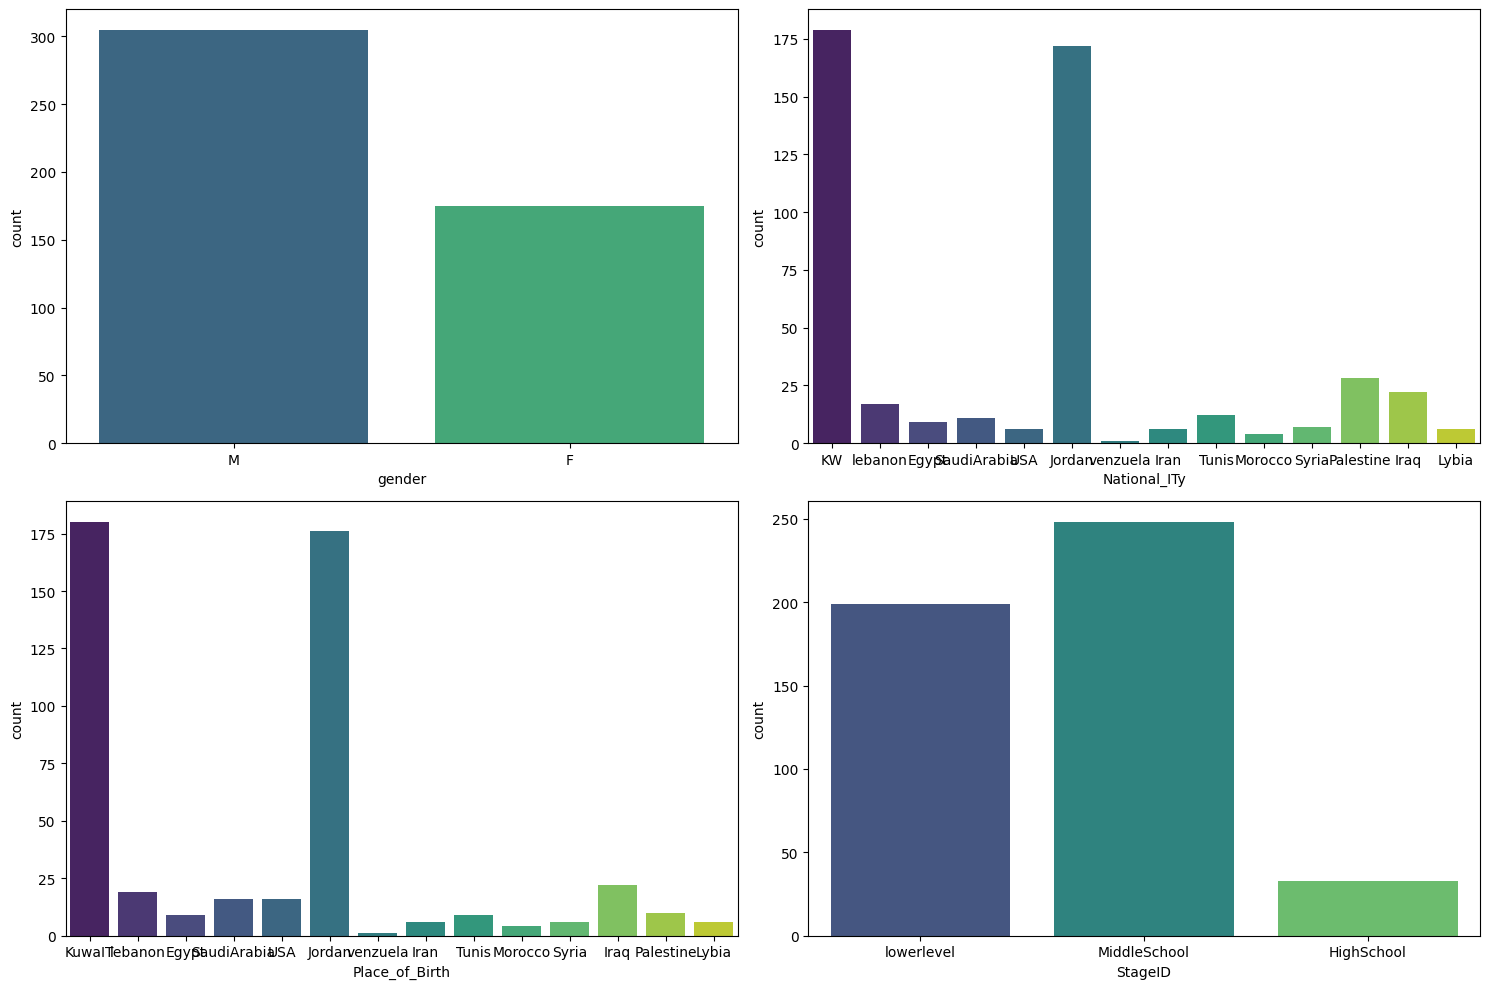

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(x='gender', data=df, ax=axs[0,0], hue='gender', palette='viridis', legend=False)
sns.countplot(x='National_ITy', data=df, ax=axs[0,1], hue='National_ITy', palette='viridis', legend=False)
sns.countplot(x='Place_of_Birth', data=df, ax=axs[1,0], hue='Place_of_Birth', palette='viridis', legend=False)
sns.countplot(x='StageID', data=df, ax=axs[1,1], hue='StageID', palette='viridis', legend=False)

plt.tight_layout()
plt.show()

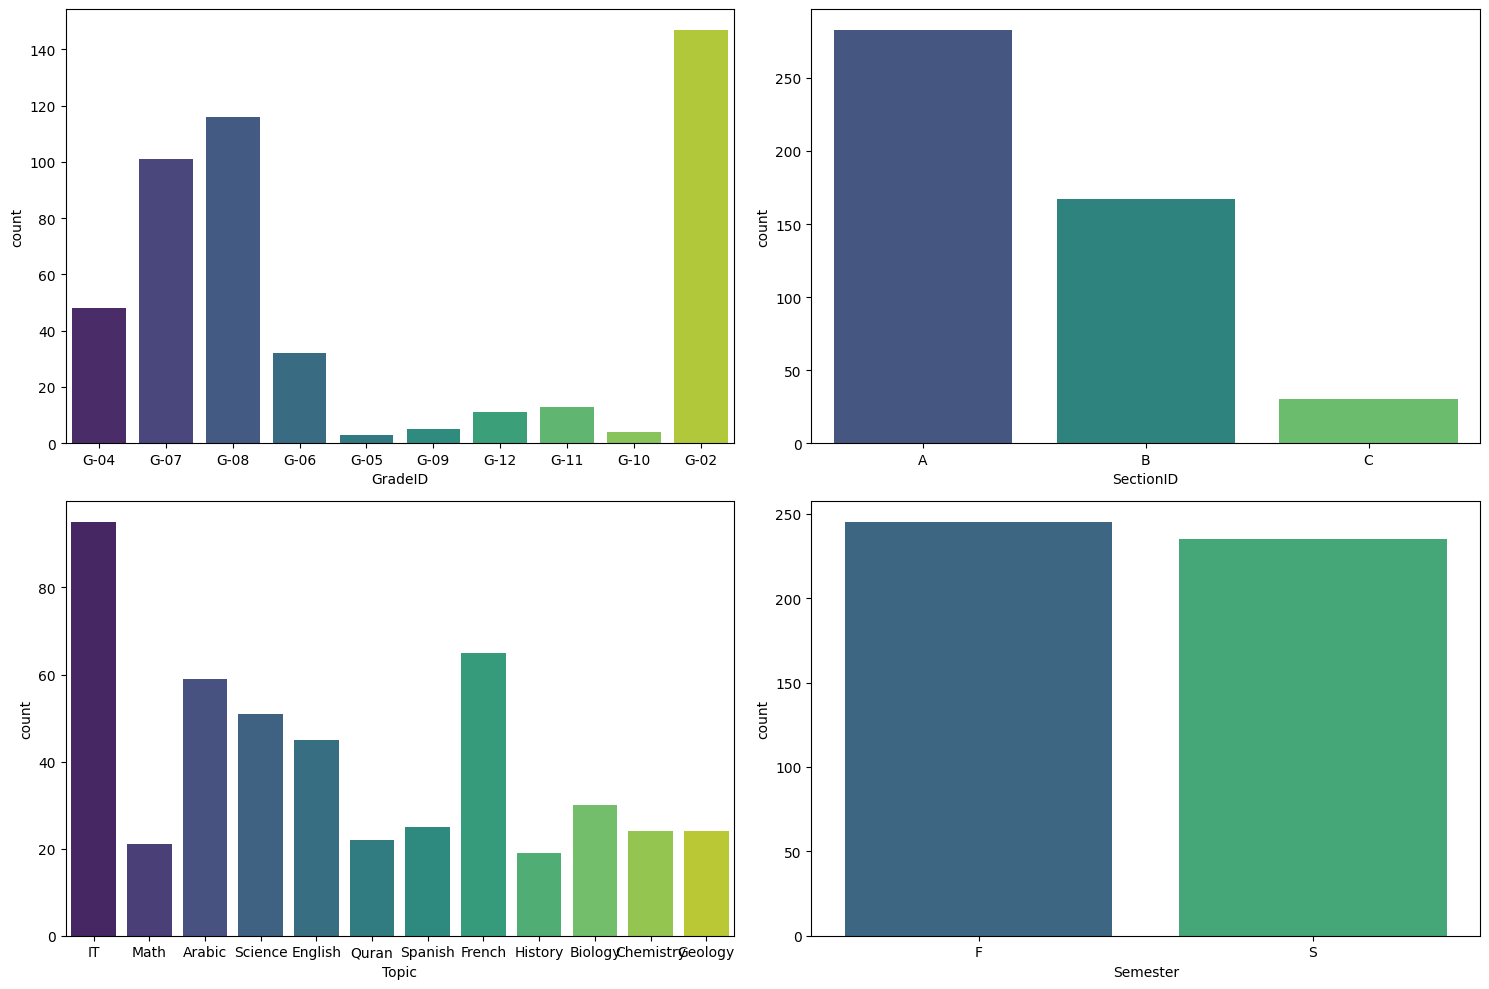

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(x='GradeID', data=df, ax=axs[0,0], hue='GradeID', palette='viridis', legend=False)
sns.countplot(x='SectionID', data=df, ax=axs[0,1], hue='SectionID', palette='viridis', legend=False)
sns.countplot(x='Topic', data=df, ax=axs[1,0], hue='Topic', palette='viridis', legend=False)
sns.countplot(x='Semester', data=df, ax=axs[1,1], hue='Semester', palette='viridis', legend=False)

plt.tight_layout()
plt.show()

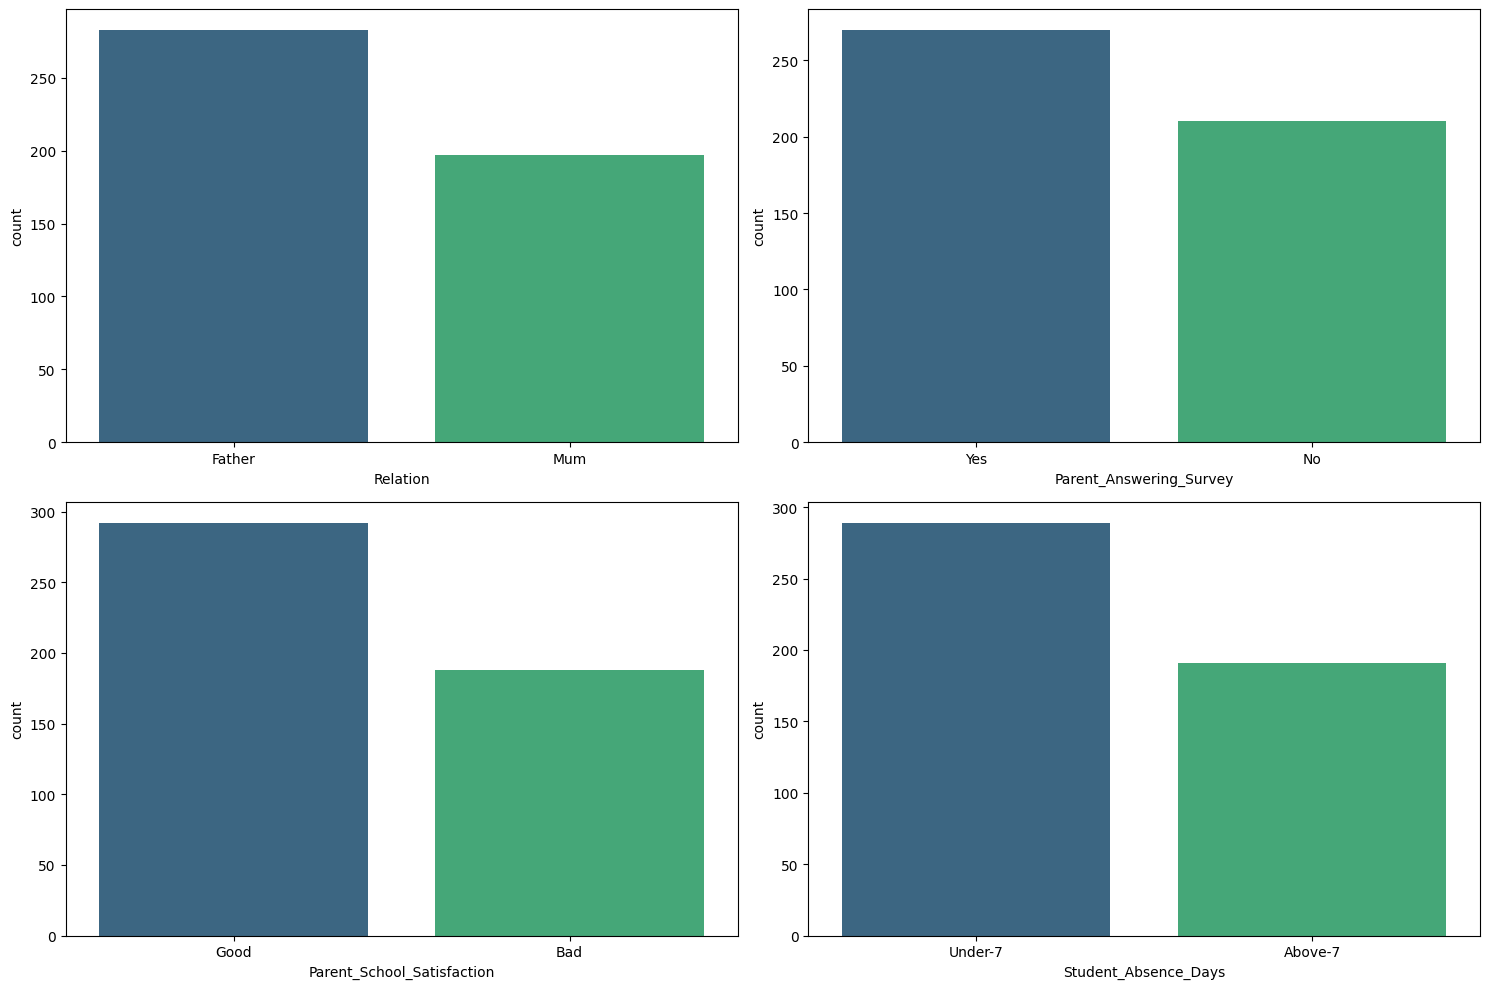

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(x='Relation', data=df, ax=axs[0,0], hue='Relation', palette='viridis', legend=False)
sns.countplot(x='Parent_Answering_Survey', data=df, ax=axs[0,1], hue='Parent_Answering_Survey', palette='viridis', legend=False)
sns.countplot(x='Parent_School_Satisfaction', data=df, ax=axs[1,0], hue='Parent_School_Satisfaction', palette='viridis', legend=False)
sns.countplot(x='Student_Absence_Days', data=df, ax=axs[1,1], hue='Student_Absence_Days', palette='viridis', legend=False)

plt.tight_layout()
plt.show()

Next, let's examine the distributions of numerical features and their correlations.

/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')


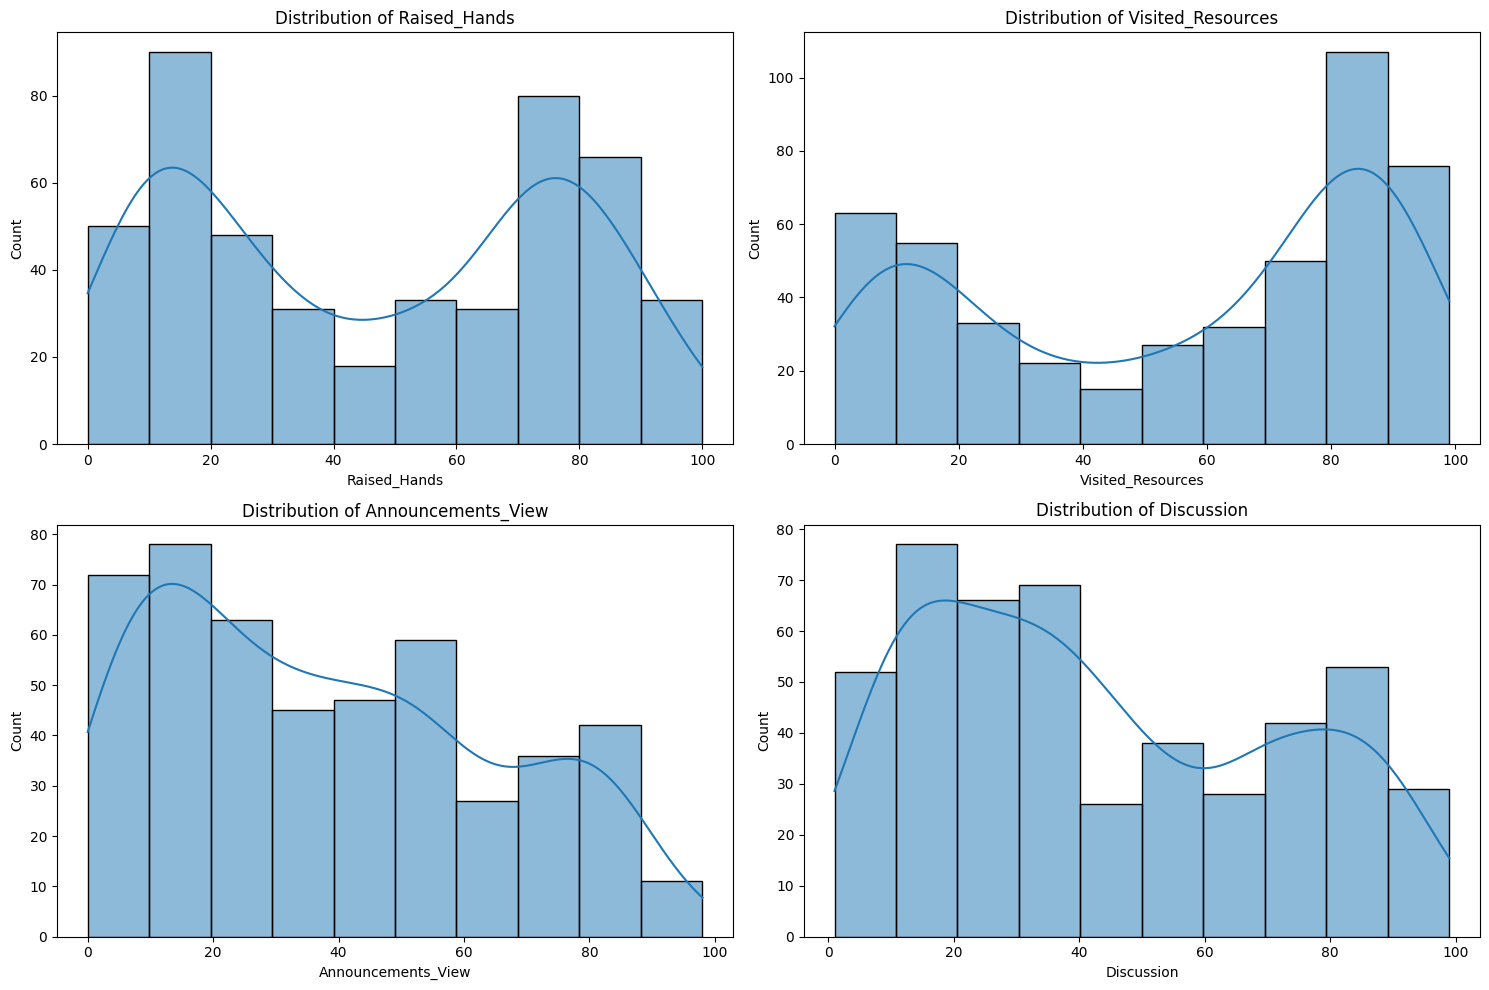

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

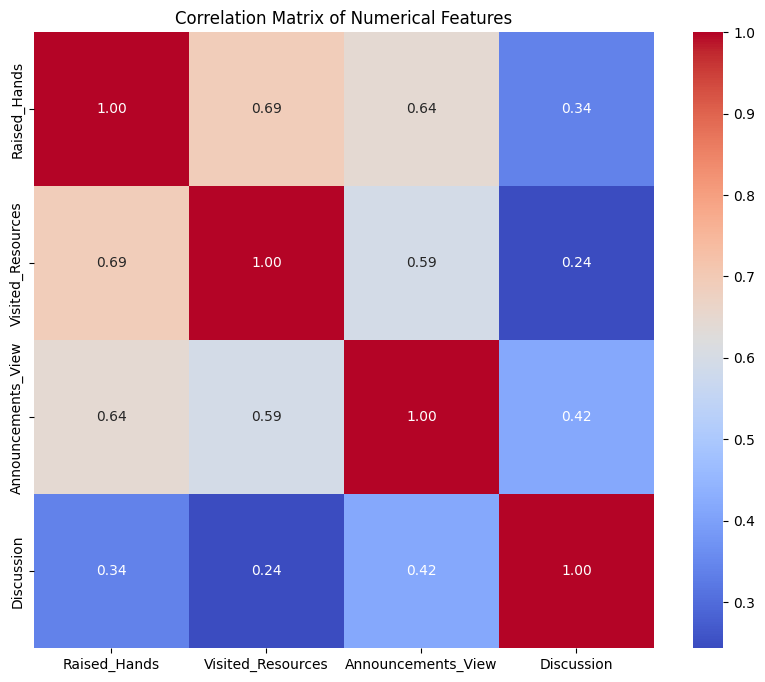

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Model Building: K-Nearest Neighbors (KNN) Classification

Before building the model, we need to preprocess the data. This involves encoding categorical features and scaling numerical features.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Apply Label Encoding to categorical columns
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# Apply StandardScaler to numerical columns
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

display(X.head())

,gender,National_ITy,Place_of_Birth,StageID,GradeID,SectionID,Topic,Semester,Relation,Raised_Hands,Visited_Resources,Announcements_View,Discussion,Parent_Answering_Survey,Parent_School_Satisfaction,Student_Absence_Days
0,1,4,4,2,1,0,7,0,0,-1.033429,-1.174075,-1.351167,-0.843326,1,1,1
1,1,4,4,2,1,0,7,0,0,-0.870813,-1.053029,-1.313549,-0.662225,1,1,1
2,1,4,4,2,1,0,7,0,0,-1.196046,-1.446426,-1.426401,-0.481125,0,0,0
3,1,4,4,2,1,0,7,0,0,-0.545579,-0.901723,-1.238315,-0.300024,0,0,0
4,1,4,4,2,1,0,7,0,0,-0.220346,-0.145191,-0.974994,0.243279,0,0,0


The data has been preprocessed by encoding categorical variables and scaling numerical features. Now, let's split the data into training and testing sets.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (336, 16)
X_test shape: (144, 16)
y_train shape: (336,)
y_test shape: (144,)


With the data preprocessed and split, let's train our KNN model and evaluate its performance.

In [ ]:
# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5) # You can experiment with n_neighbors
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6388888888888888

Classification Report:
               precision    recall  f1-score   support

           H       0.61      0.63      0.62        43
           L       0.68      0.74      0.71        38
           M       0.63      0.59      0.61        63

    accuracy                           0.64       144
   macro avg       0.64      0.65      0.65       144
weighted avg       0.64      0.64      0.64       144


Confusion Matrix:
 [[27  3 13]
 [ 1 28  9]
 [16 10 37]]


The KNN model has been trained and evaluated. The results provide insights into its accuracy and performance on different classes.

With the data preprocessed and split, let's train our KNN model and evaluate its performance.

In [ ]:
# Initialize and train the KNN model
knn = KNeighborsClassifier(n_neighbors=5) # You can experiment with n_neighbors
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.6388888888888888

Classification Report:
               precision    recall  f1-score   support

           H       0.61      0.63      0.62        43
           L       0.68      0.74      0.71        38
           M       0.63      0.59      0.61        63

    accuracy                           0.64       144
   macro avg       0.64      0.65      0.65       144
weighted avg       0.64      0.64      0.64       144


Confusion Matrix:
 [[27  3 13]
 [ 1 28  9]
 [16 10 37]]


The KNN model has been trained and evaluated. The results provide insights into its accuracy and performance on different classes.

We've now performed an initial Exploratory Data Analysis by checking for null values, examining unique categories, visualizing the distribution of categorical features, and plotting histograms and correlations for numerical features. This completes the basic EDA phase.

Next, let's examine the distributions of numerical features and their correlations.

/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')


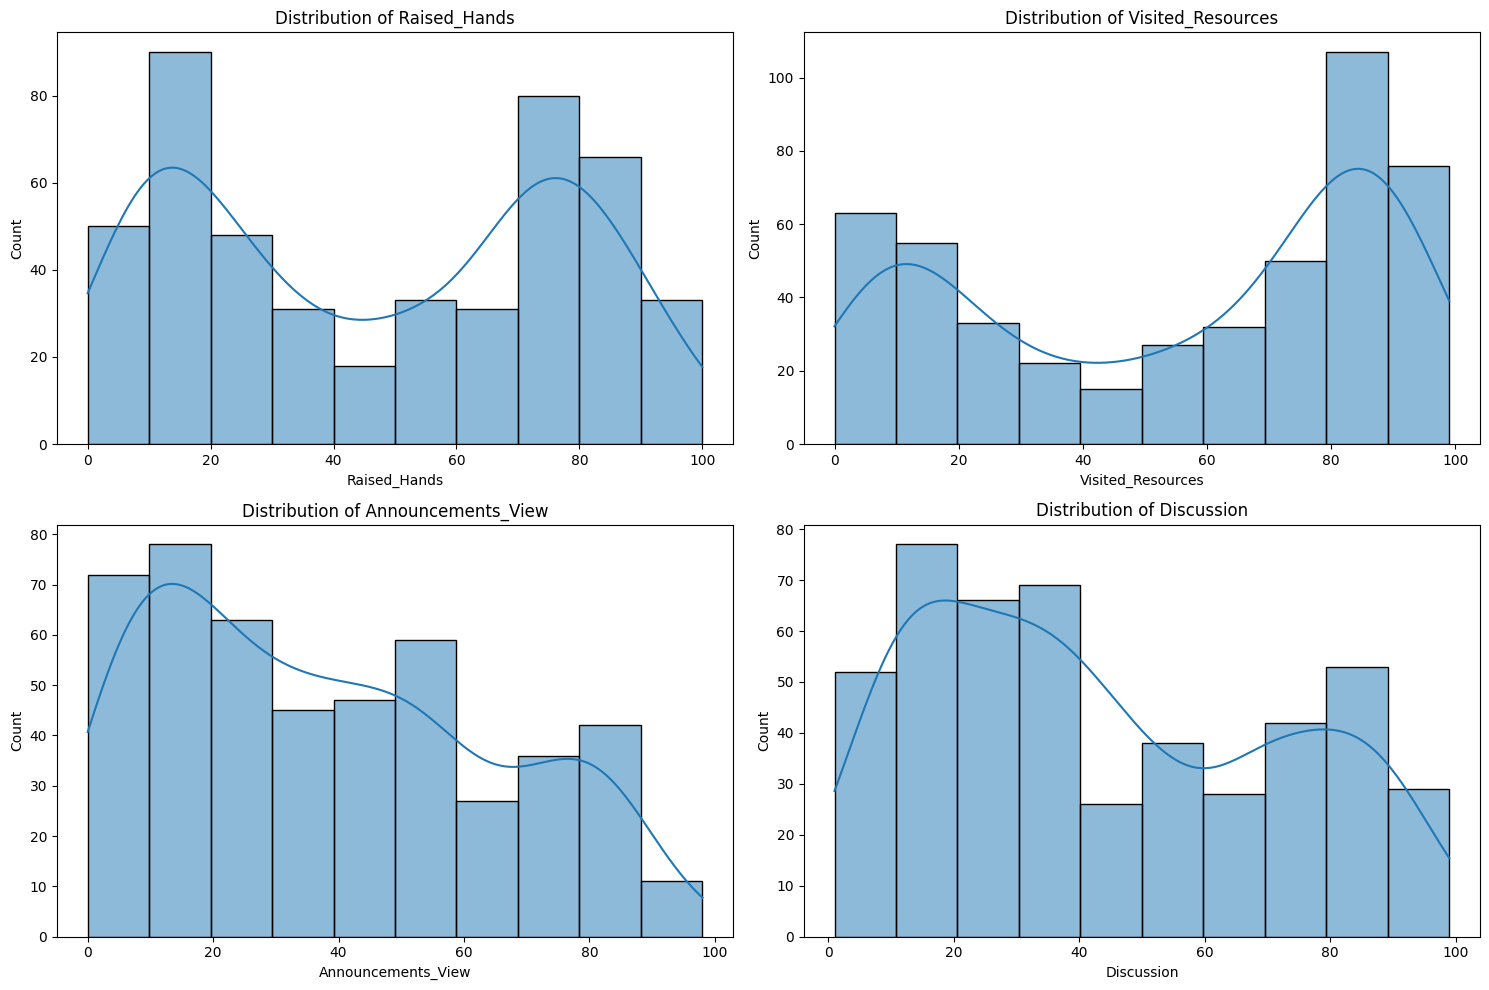

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

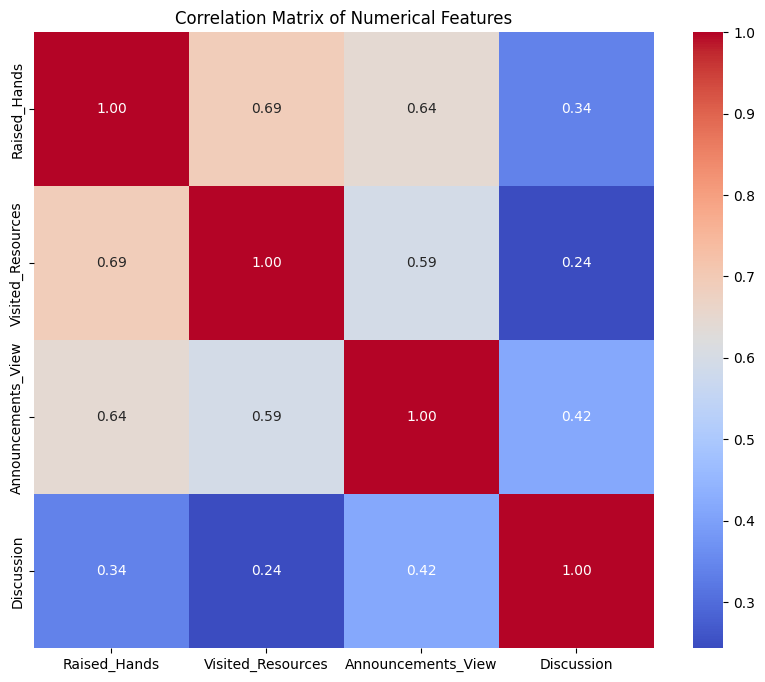

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

We've now performed an initial Exploratory Data Analysis by checking for null values, examining unique categories, visualizing the distribution of categorical features, and plotting histograms and correlations for numerical features. This completes the basic EDA phase.

Next, let's examine the distributions of numerical features and their correlations.

/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
/tmp/ipykernel_9412/2728668701.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')


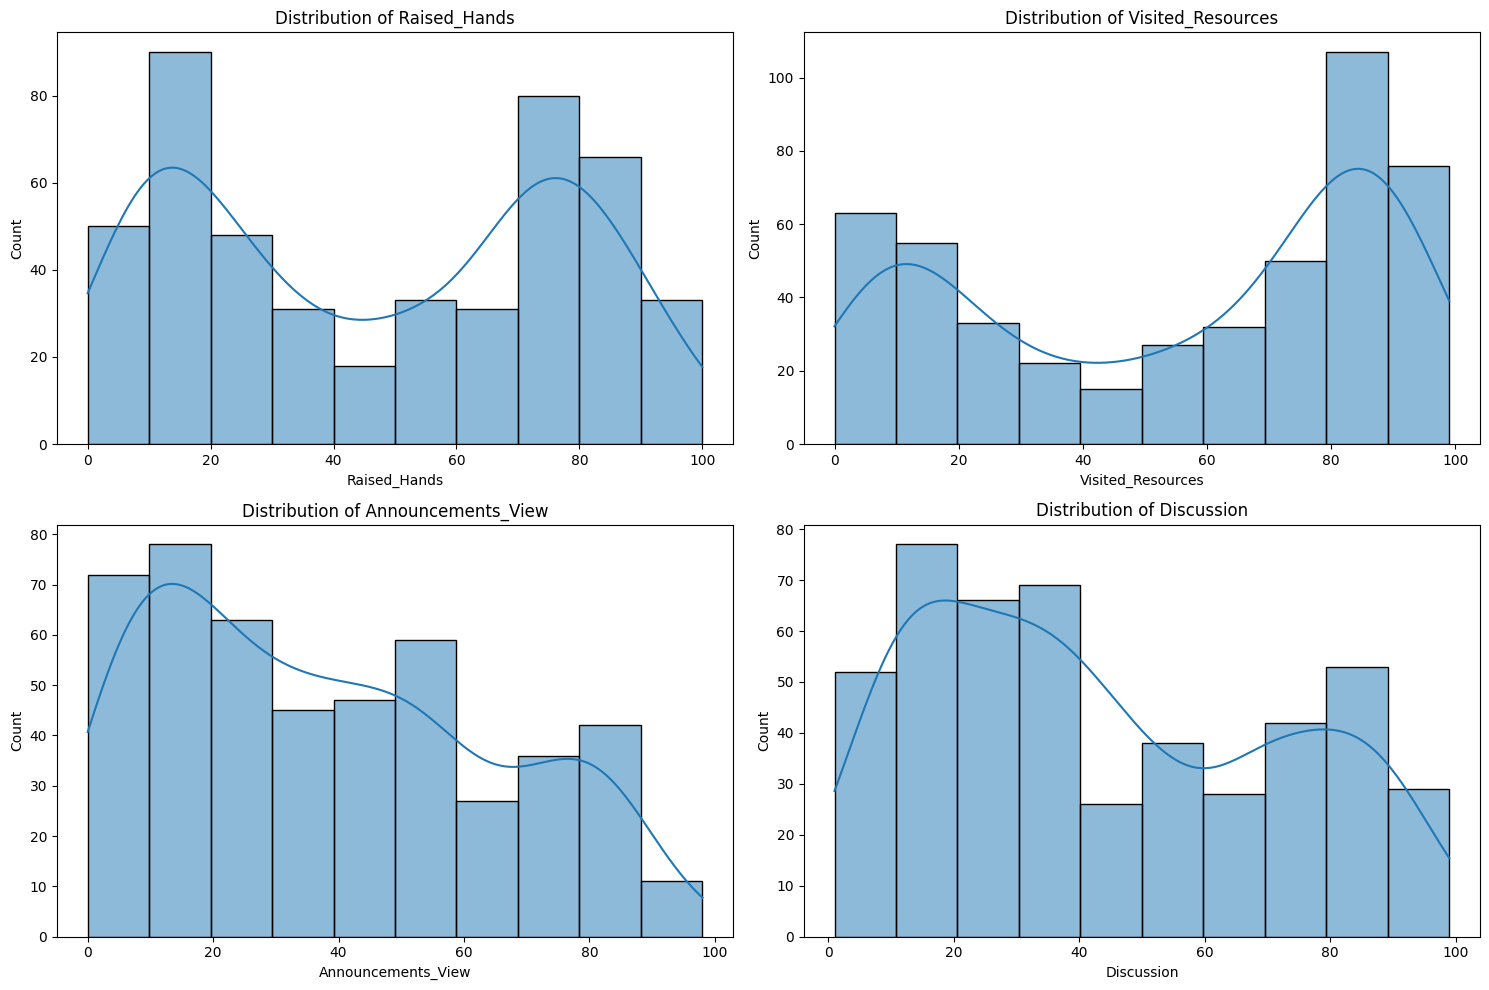

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

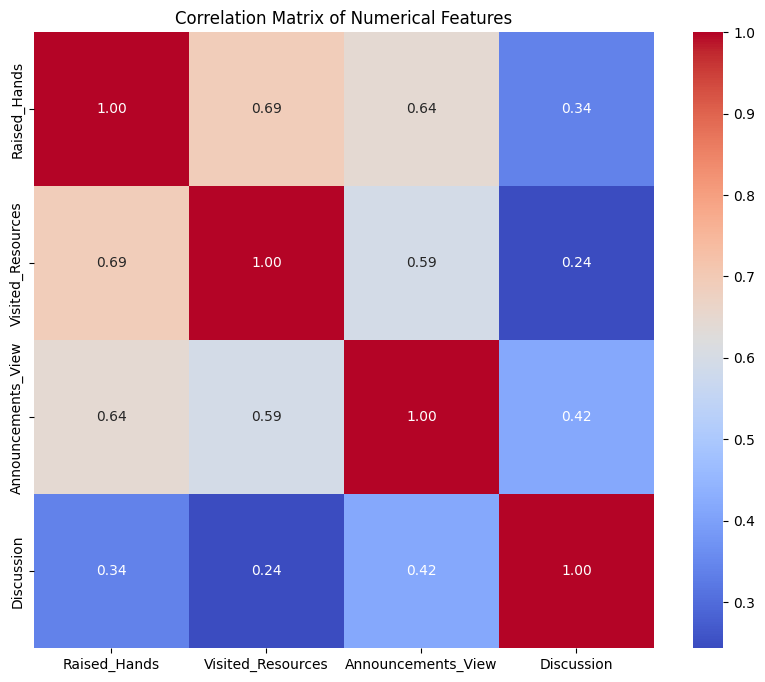

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
#model building
#KNN classification
# KNN is the distance based algo and because of this we are going to perform  standard scalling

In [ ]:
#to perform eda
#encoding all object type columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

cat_cols.remove('Class')
df_copy = pd.get_dummies(df,columns = cat_cols)

df['Class']= df['Class'].map({'L':0,'M':1,'H':2})

In [ ]:
from sklearn.model_selection import train_test_split
x = df_copy.drop('Class', axis=1)
y = df['Class']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [ ]:
#standar scalling -> to avoid data leakage
from sklearn.preprocessing import StandardScaler

# mean =0, st deviation = 2, z-score=x-mean/std deviation
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [ ]:
#model building
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
score=[] #we are storing accuracy for each k value(1 to 20 )
train_score=[]
for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)#prediction


    accuracy=accuracy_score(y_test,y_pred) #testing accuracy
    train=accuracy_score(y_train,knn.predict(x_train))
    score.append(accuracy)
    train_score.append(train)
    print(f"Accuracy for k={k}: {accuracy}")

Accuracy for k=1: 0.7291666666666666
Accuracy for k=2: 0.6354166666666666
Accuracy for k=3: 0.6770833333333334
Accuracy for k=4: 0.6145833333333334
Accuracy for k=5: 0.6458333333333334
Accuracy for k=6: 0.6041666666666666
Accuracy for k=7: 0.6458333333333334
Accuracy for k=8: 0.59375
Accuracy for k=9: 0.59375
Accuracy for k=10: 0.53125
Accuracy for k=11: 0.59375
Accuracy for k=12: 0.5416666666666666
Accuracy for k=13: 0.5520833333333334
Accuracy for k=14: 0.5208333333333334
Accuracy for k=15: 0.5625
Accuracy for k=16: 0.5729166666666666
Accuracy for k=17: 0.59375
Accuracy for k=18: 0.5729166666666666
Accuracy for k=19: 0.5416666666666666
Accuracy for k=20: 0.59375


In [ ]:
 print(f" train_Accuracy for k={k}: {train}")

 train_Accuracy for k=20: 0.6744791666666666


In [ ]:
model=KNeighborsClassifier()
model.fit(x_train,y_train)#training KNN model


KNeighborsClassifier()

In [ ]:
y_pred=model.predict(x_test)

<Axes: >

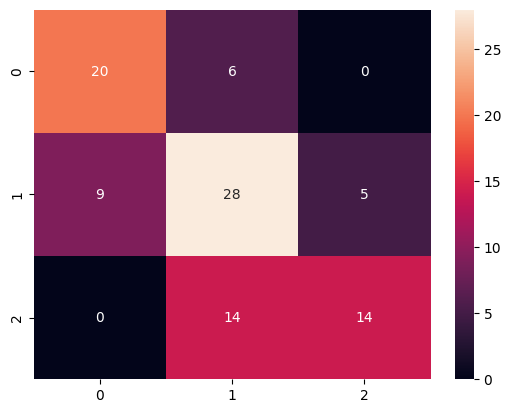

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)


In [ ]:
accuracy_score(y_test,y_pred)

0.6458333333333334

In [ ]:
accuracy_score(y_train,model.predict(x_train))

0.7421875

In [ ]:
model

KNeighborsClassifier()

In [ ]:
# importing the model to create UI
import joblib
joblib.dump(accuracy_score,'KNN_model.pkl')

['KNN_model.pkl']